  SGNG_NM  FEMALE_2039  POP_65_OVER  EXTINCTION_INDEX  YEAR
0     군위군       978.61     10180.60          0.096125  2022
1     의성군      2260.78     22487.08          0.100537  2022
2     봉화군      1321.91     12168.66          0.108632  2022
3     청송군      1087.82      9920.87          0.109650  2022
4     고흥군      2955.35     26926.07          0.109758  2022
Index(['SGNG_NM', 'FEMALE_2039', 'POP_65_OVER', 'EXTINCTION_INDEX', 'YEAR'], dtype='str')


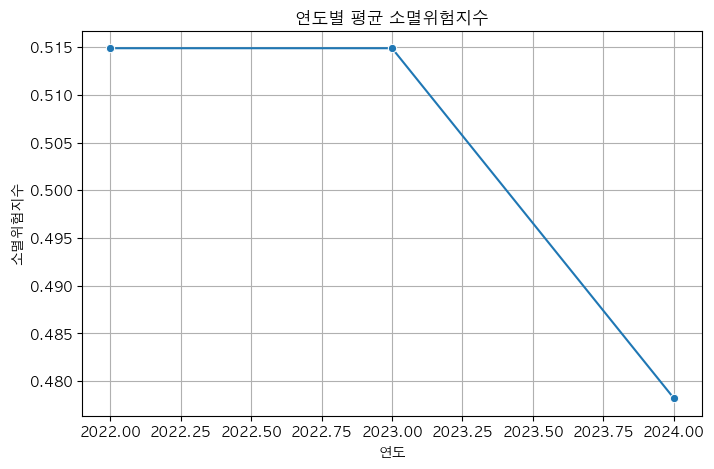

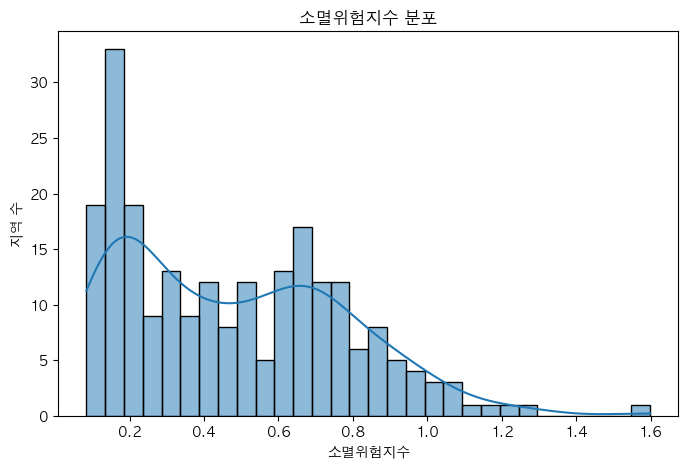

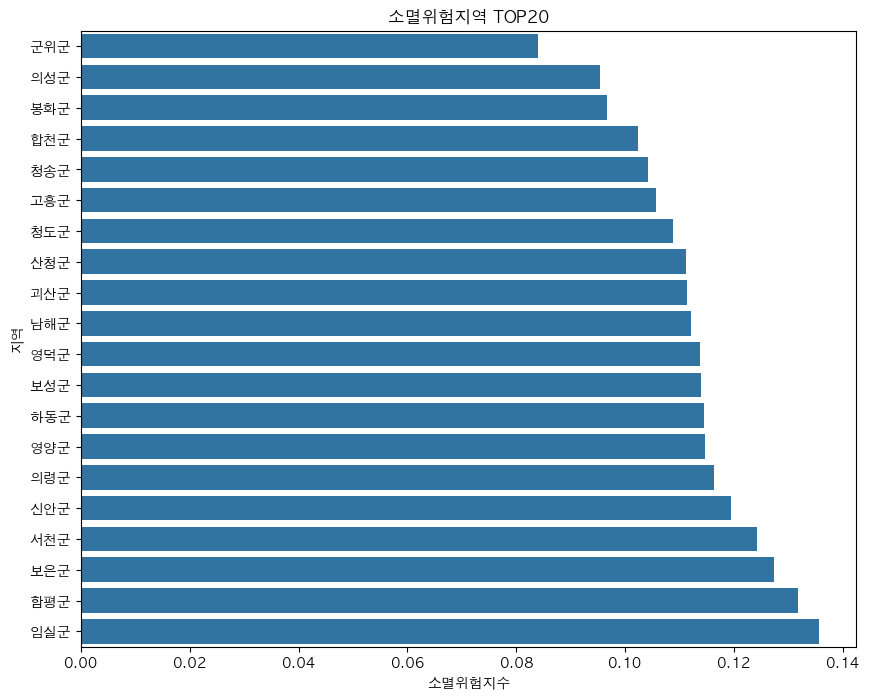

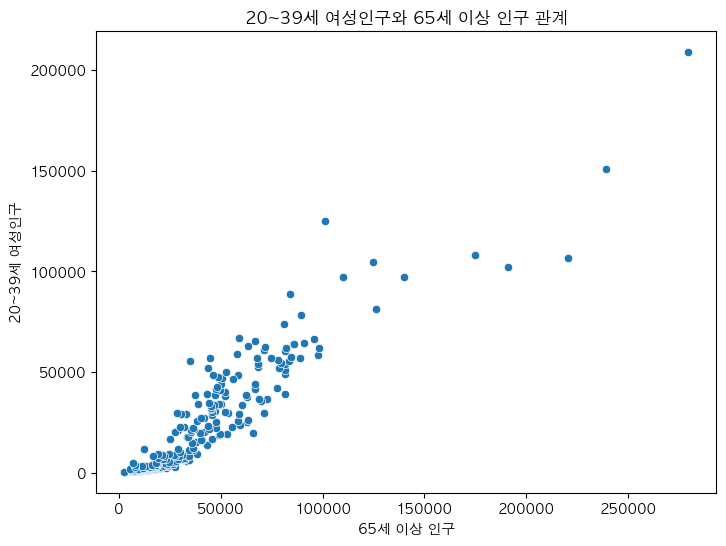

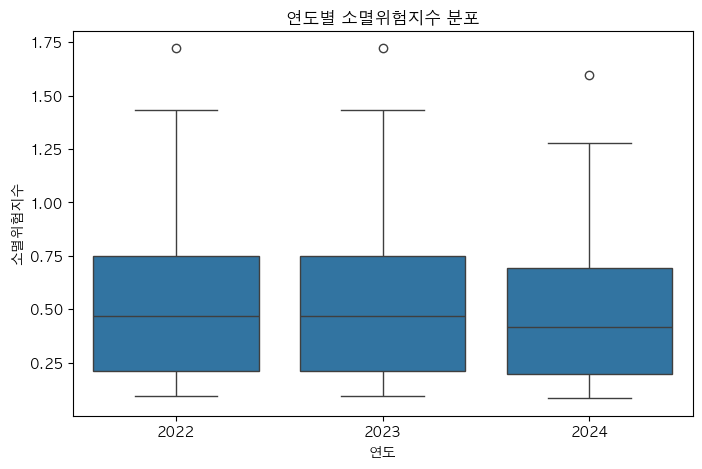

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

# -----------------------------
# 데이터 불러오기
# -----------------------------
df2022 = pd.read_excel("data/위험지수2022.xlsx")
df2023 = pd.read_excel("data/위험지수2023.xlsx")
df2024 = pd.read_excel("data/위험지수2024.xlsx")

df2022["YEAR"] = 2022
df2023["YEAR"] = 2023
df2024["YEAR"] = 2024

df_all = pd.concat(
    [df2022, df2023, df2024],
    ignore_index=True
)

print(df_all.head())
print(df_all.columns)

# -----------------------------
# 연도별 평균 소멸위험지수
# -----------------------------
avg_index = (
    df_all
    .groupby("YEAR")["EXTINCTION_INDEX"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(8,5))
sns.lineplot(
    data=avg_index,
    x="YEAR",
    y="EXTINCTION_INDEX",
    marker="o"
)

plt.title("연도별 평균 소멸위험지수")
plt.xlabel("연도")
plt.ylabel("소멸위험지수")
plt.grid(True)
plt.show()

# -----------------------------
# 2024 소멸위험지수 분포
# -----------------------------
plt.figure(figsize=(8,5))

sns.histplot(
    df2024["EXTINCTION_INDEX"],
    bins=30,
    kde=True
)

plt.title("소멸위험지수 분포")
plt.xlabel("소멸위험지수")
plt.ylabel("지역 수")
plt.show()

# -----------------------------
# 위험지역 TOP20
# -----------------------------
top20 = (
    df2024
    .sort_values(
        "EXTINCTION_INDEX",
        ascending=True
    )
    .head(20)
)

plt.figure(figsize=(10,8))

sns.barplot(
    data=top20,
    y="SGNG_NM",
    x="EXTINCTION_INDEX"
)

plt.title("소멸위험지역 TOP20")
plt.xlabel("소멸위험지수")
plt.ylabel("지역")
plt.show()

# -----------------------------
# 여성인구 vs 노인인구
# -----------------------------
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df2024,
    x="POP_65_OVER",
    y="FEMALE_2039"
)

plt.title("20~39세 여성인구와 65세 이상 인구 관계")
plt.xlabel("65세 이상 인구")
plt.ylabel("20~39세 여성인구")

plt.show()

# -----------------------------
# 박스플롯
# -----------------------------
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df_all,
    x="YEAR",
    y="EXTINCTION_INDEX"
)

plt.title("연도별 소멸위험지수 분포")
plt.xlabel("연도")
plt.ylabel("소멸위험지수")

plt.show()

Index(['SGNG_NM', 'FEMALE_2039', 'POP_65_OVER', 'EXTINCTION_INDEX'], dtype='str')


/var/folders/ts/p4hxfj_d50723wnzrsszyn4m0000gn/T/ipykernel_2056/92552877.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


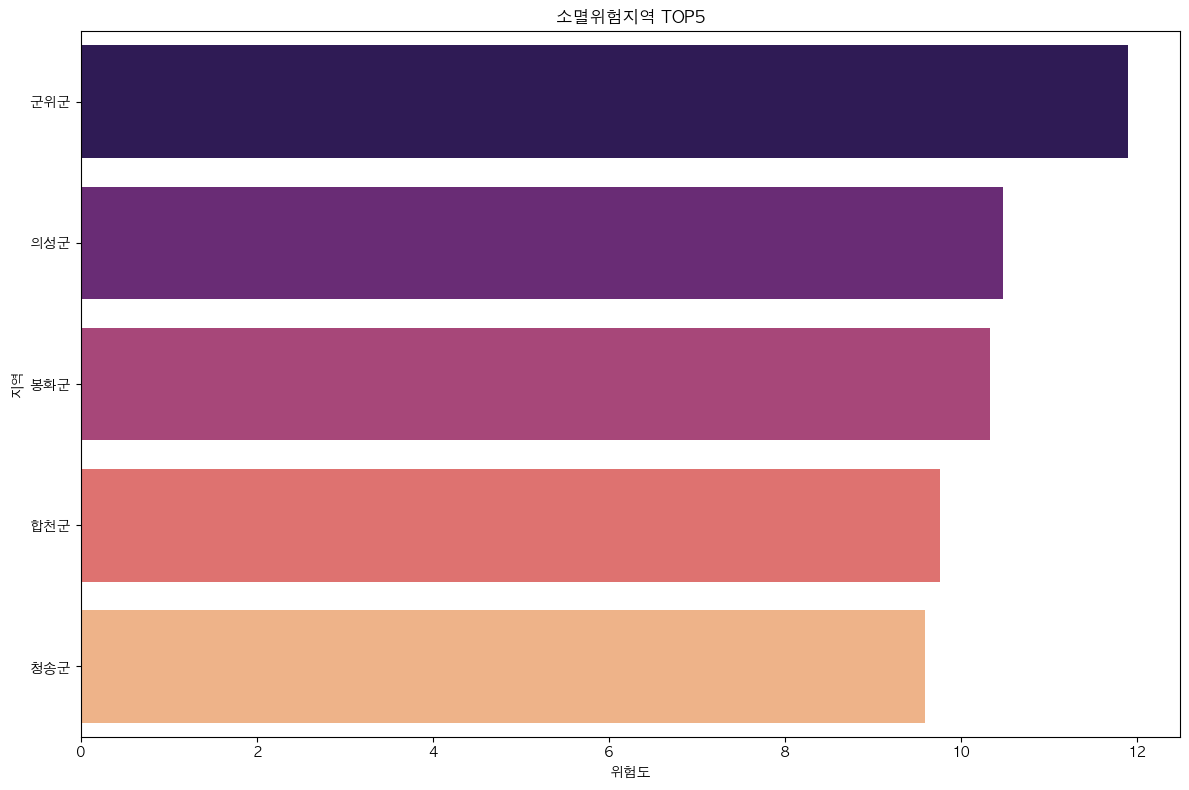

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 한글 깨짐 방지 (Mac)
plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

# -----------------------------
# 데이터 불러오기
# -----------------------------
df2022 = pd.read_excel("data/위험지수2022.xlsx")
df2023 = pd.read_excel("data/위험지수2023.xlsx")
df2024 = pd.read_excel("data/위험지수2024.xlsx")

# 전체 데이터 합치기
df_all = pd.concat(
    [df2022, df2023, df2024],
    ignore_index=True
)

# 컬럼 확인
print(df2024.columns)

# -----------------------------
# 위험도 계산
# -----------------------------
# 소멸위험지수가 낮을수록 위험하므로 역수 사용

df2024["위험도"] = 1 / df2024["EXTINCTION_INDEX"]

# 위험도 높은 순으로 TOP20 추출
top20 = (
    df2024
    .sort_values("위험도", ascending=False)
    .head(5)
)

# -----------------------------
# 그래프 그리기
# -----------------------------
plt.figure(figsize=(12,8))

colors = sns.color_palette("magma", len(top20))

sns.barplot(
    data=top20,
    y="SGNG_NM",
    x="위험도",
    palette=colors
)

plt.title("소멸위험지역 TOP5")
plt.xlabel("위험도")
plt.ylabel("지역")

plt.tight_layout()
plt.show()
